In [6]:
import pandas as pd
df = pd.read_csv("datascience_salaries.csv")

In [7]:
df.head()

,Unnamed: 0,job_title,job_type,experience_level,location,salary_currency,salary
0,0,Data scientist,Full Time,Senior,New York City,USD,149000
1,2,Data scientist,Full Time,Senior,Boston,USD,120000
2,3,Data scientist,Full Time,Senior,London,USD,68000
3,4,Data scientist,Full Time,Senior,Boston,USD,120000
4,5,Data scientist,Full Time,Senior,New York City,USD,149000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1171 entries, 0 to 1170
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1171 non-null   int64
 1   job_title         1171 non-null   str  
 2   job_type          1171 non-null   str  
 3   experience_level  1171 non-null   str  
 4   location          1171 non-null   str  
 5   salary_currency   1171 non-null   str  
 6   salary            1171 non-null   int64
dtypes: int64(2), str(5)
memory usage: 64.2 KB


In [14]:
# Rename the "Unnamed: 0" column to "id"
df = df.rename(columns={"Unnamed: 0": "id"})

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1171 entries, 0 to 1170
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id                1171 non-null   int64
 1   job_title         1171 non-null   str  
 2   job_type          1171 non-null   str  
 3   experience_level  1171 non-null   str  
 4   location          1171 non-null   str  
 5   salary_currency   1171 non-null   str  
 6   salary            1171 non-null   int64
dtypes: int64(2), str(5)
memory usage: 64.2 KB


In [16]:
df.describe()

,id,salary
count,1171.000000,1171.000000
mean,931.620837,64836.037575
std,647.445266,32551.767046
min,0.000000,30000.000000
25%,364.500000,45000.000000
50%,815.000000,63000.000000
75%,1504.500000,68000.000000
max,2259.000000,228000.000000


In [19]:
# Check the salary_currency column more closely
print("Unique currencies:")
print(df["salary_currency"].unique())
print("\nCurrency distribution:")
print(df["salary_currency"].value_counts())


Unique currencies:
<StringArray>
['USD', 'EUR', 'GBP']
Length: 3, dtype: str

Currency distribution:
salary_currency
USD    1157
EUR       9
GBP       5
Name: count, dtype: int64


In [21]:
# Define currency conversion rates to USD
# Note: These are approximate rates. Update with current rates if needed.
conversion_rates = {
    "USD": 1.0,
    "EUR": 1.10,      # 1 EUR ≈ 1.10 USD
    "GBP": 1.27,      # 1 GBP ≈ 1.27 USD
}

print("Conversion rates to USD:")
for currency, rate in conversion_rates.items():
    print(f"{currency}: {rate}")


Conversion rates to USD:
USD: 1.0
EUR: 1.1
GBP: 1.27


In [22]:
# Create a function to convert salary to USD
def convert_to_usd(row):
    """
    Convert salary to USD based on currency
    """
    salary = row['salary']
    currency = row['salary_currency']
    
    # Get the conversion rate, default to 1.0 if currency not found
    rate = conversion_rates.get(currency, 1.0)
    
    return salary * rate

# Apply the conversion function to create a new column
df['salary_usd'] = df.apply(convert_to_usd, axis=1)

print("Conversion successful!")
print(f"\nOriginal salary columns: salary, salary_currency")
print(f"New column created: salary_usd")
print(f"\nFirst 5 rows (salary comparison):")
print(df[['salary', 'salary_currency', 'salary_usd']].head(10))


Conversion successful!

Original salary columns: salary, salary_currency
New column created: salary_usd

First 5 rows (salary comparison):
   salary salary_currency  salary_usd
0  149000             USD    149000.0
1  120000             USD    120000.0
2   68000             USD     68000.0
3  120000             USD    120000.0
4  149000             USD    149000.0
5   68000             USD     68000.0
6   69000             USD     69000.0
7   68000             USD     68000.0
8  140000             USD    140000.0
9   68000             USD     68000.0


In [23]:
# Verify the conversion by showing statistics by currency
print("Salary statistics by original currency:")
print("\nOriginal Salaries:")
print(df.groupby('salary_currency')['salary'].agg(['count', 'mean', 'min', 'max']))

print("\n" + "="*70)
print("\nConverted to USD:")
print(df.groupby('salary_currency')['salary_usd'].agg(['count', 'mean', 'min', 'max']))

print("\n" + "="*70)
print(f"\nAll salaries are now normalized to USD!")
print(f"Original data types: salary ({df['salary'].dtype}), salary_currency ({df['salary_currency'].dtype})")
print(f"New USD salary type: {df['salary_usd'].dtype}")


Salary statistics by original currency:

Original Salaries:
                 count          mean    min     max
salary_currency                                    
EUR                  9  47222.222222  36000   70000
GBP                  5  50400.000000  40000   65000
USD               1157  65035.436474  30000  228000


Converted to USD:
                 count          mean      min       max
salary_currency                                        
EUR                  9  51944.444444  39600.0   77000.0
GBP                  5  64008.000000  50800.0   82550.0
USD               1157  65035.436474  30000.0  228000.0


All salaries are now normalized to USD!
Original data types: salary (int64), salary_currency (str)
New USD salary type: float64


In [24]:
# Delete the salary_currency column since everything is now in USD
df = df.drop(columns=['salary_currency'])

print("Deleted 'salary_currency' column")
print(f"\nDataFrame columns: {df.columns.tolist()}")
print(f"\nDataFrame shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())


Deleted 'salary_currency' column

DataFrame columns: ['id', 'job_title', 'job_type', 'experience_level', 'location', 'salary', 'salary_usd']

DataFrame shape: (1171, 7)

First few rows:
   id       job_title   job_type experience_level       location  salary  \
0   0  Data scientist  Full Time           Senior  New York City  149000   
1   2  Data scientist  Full Time           Senior         Boston  120000   
2   3  Data scientist  Full Time           Senior         London   68000   
3   4  Data scientist  Full Time           Senior         Boston  120000   
4   5  Data scientist  Full Time           Senior  New York City  149000   

   salary_usd  
0    149000.0  
1    120000.0  
2     68000.0  
3    120000.0  
4    149000.0  


In [25]:
# Copy salary_usd values to salary and delete salary_usd
df['salary'] = df['salary_usd']
df = df.drop(columns=['salary_usd'])

print("Updated salary column with USD values and deleted 'salary_usd'")
print(f"\nDataFrame columns: {df.columns.tolist()}")
print(f"\nDataFrame shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())


Updated salary column with USD values and deleted 'salary_usd'

DataFrame columns: ['id', 'job_title', 'job_type', 'experience_level', 'location', 'salary']

DataFrame shape: (1171, 6)

First few rows:
   id       job_title   job_type experience_level       location    salary
0   0  Data scientist  Full Time           Senior  New York City  149000.0
1   2  Data scientist  Full Time           Senior         Boston  120000.0
2   3  Data scientist  Full Time           Senior         London   68000.0
3   4  Data scientist  Full Time           Senior         Boston  120000.0
4   5  Data scientist  Full Time           Senior  New York City  149000.0


In [17]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [28]:
# MinMaxScaler: range [0, 1] (good for skewed data or when a bounded range is needed)
min_max_scaler = MinMaxScaler()

# Features that are skewed: Fare and Fare_Log
# These have outliers even after capping, and MinMaxScaler handles bounded ranges well
features_for_minmax = ["salary"]
df[features_for_minmax] = min_max_scaler.fit_transform(
    df[features_for_minmax]
)

In [27]:
df.head()

,id,job_title,job_type,experience_level,location,salary
0,0,Data scientist,Full Time,Senior,New York City,0.601010
1,2,Data scientist,Full Time,Senior,Boston,0.454545
2,3,Data scientist,Full Time,Senior,London,0.191919
3,4,Data scientist,Full Time,Senior,Boston,0.454545
4,5,Data scientist,Full Time,Senior,New York City,0.601010


In [29]:
# Step 1: Prepare data for dimensionality reduction
# Select only numerical features
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Remove target variable if it exists (e.g., 'id', 'salary')
# For this dataset, we'll keep all numerical features for demonstration
X = df[numerical_features]

print("Features for dimensionality reduction:")
print(f"Number of features: {X.shape[1]}")
print(f"Features: {numerical_features}")
print(f"\nDataset shape: {X.shape}")

# Check if data needs standardization
print(f"\nFeature statistics before standardization:")
print(X.describe())


Features for dimensionality reduction:
Number of features: 2
Features: ['id', 'salary']

Dataset shape: (1171, 2)

Feature statistics before standardization:
                id       salary
count  1171.000000  1171.000000
mean    931.620837     0.176416
std     647.445266     0.164286
min       0.000000     0.000000
25%     364.500000     0.075758
50%     815.000000     0.166667
75%    1504.500000     0.191919
max    2259.000000     1.000000


In [30]:
# Step 2: Standardize the data (important for PCA)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data standardized for PCA")
print(f"Scaled data shape: {X_scaled.shape}")
print(f"Mean of scaled data: {X_scaled.mean(axis=0).mean():.6f}")
print(f"Std of scaled data: {X_scaled.std(axis=0).mean():.6f}")


Data standardized for PCA
Scaled data shape: (1171, 2)
Mean of scaled data: 0.000000
Std of scaled data: 1.000000


In [31]:
# Step 3: Apply PCA to reduce dimensions
# Keep components that explain 95% of the variance
pca = PCA(n_components=0.95)  # Keeps 95% of variance
X_pca = pca.fit_transform(X_scaled)

print("PCA Applied Successfully!")
print(f"Original number of features: {X_scaled.shape[1]}")
print(f"Reduced number of features: {X_pca.shape[1]}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)")
print(f"\nVariance explained by each component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    cumsum = pca.explained_variance_ratio_[:i+1].sum()
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%) | Cumulative: {cumsum:.4f} ({cumsum*100:.2f}%)")


PCA Applied Successfully!
Original number of features: 2
Reduced number of features: 2
Variance explained: 1.0000 (100.00%)

Variance explained by each component:
PC1: 0.5054 (50.54%) | Cumulative: 0.5054 (50.54%)
PC2: 0.4946 (49.46%) | Cumulative: 1.0000 (100.00%)


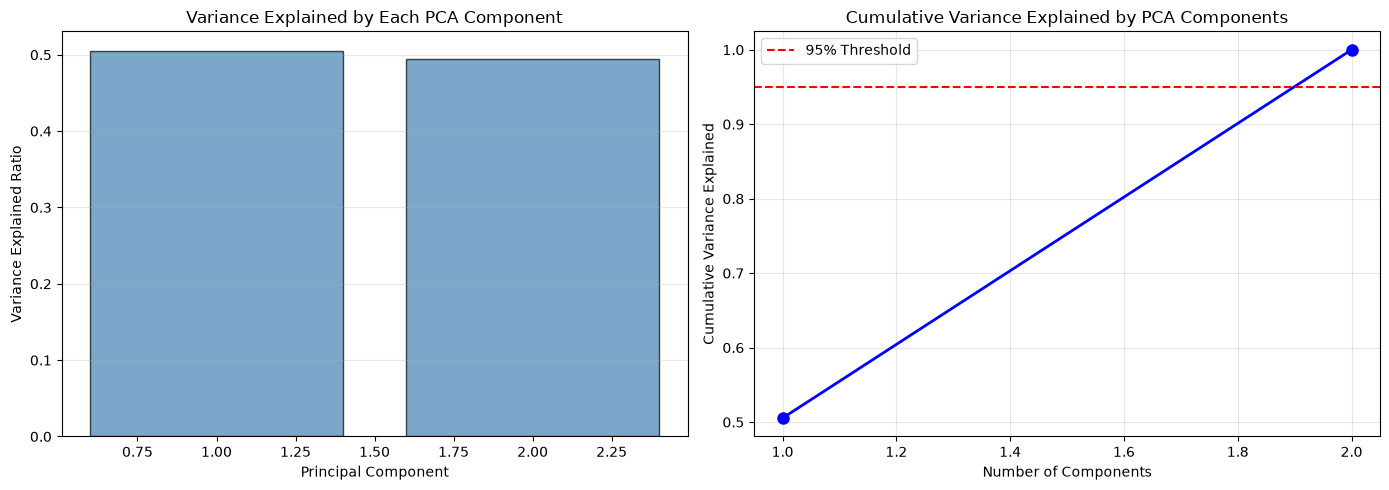

Reduction achieved: 0.00% fewer features


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize variance explained
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Variance explained by each component
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), 
            pca.explained_variance_ratio_, 
            alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained Ratio')
axes[0].set_title('Variance Explained by Each PCA Component')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Cumulative variance explained
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, len(cumsum_var) + 1), cumsum_var, 'bo-', linewidth=2, markersize=8)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Variance Explained by PCA Components')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Reduction achieved: {((X_scaled.shape[1] - X_pca.shape[1]) / X_scaled.shape[1] * 100):.2f}% fewer features")


In [46]:
# Step 4: Apply t-SNE for visualization (reduces to 2D for plotting)
from sklearn.manifold import TSNE

# Note: t-SNE is computationally expensive, so we'll use first few PCA components as input
# to speed up the computation
print("Applying t-SNE (this may take a moment)...")

# Dynamically determine number of components (can't exceed number of features)
n_features = X_scaled.shape[1]
n_components_intermediate = min(n_features - 1, 10)  # Leave at least 1 component

print(f"Dataset has {n_features} features")
print(f"Using {n_components_intermediate} intermediate PCA components for t-SNE input")

if n_components_intermediate > 0:
    # Use intermediate PCA to reduce computation
    pca_intermediate = PCA(n_components=n_components_intermediate)
    X_pca_intermediate = pca_intermediate.fit_transform(X_scaled)
else:
    # If only 1 feature, use it directly
    X_pca_intermediate = X_scaled

# Apply t-SNE with adaptive perplexity and n_components
n_samples = X_pca_intermediate.shape[0]
n_features_intermediate = X_pca_intermediate.shape[1]

# Perplexity should be less than n_samples/3
perplexity = min(30, max(5, n_samples // 3 - 1))

# t-SNE n_components can't exceed the number of input features
# If we only have 1 feature, we can't create 2 t-SNE components
tsne_n_components = min(2, n_features_intermediate)

print(f"Number of samples: {n_samples}")
print(f"Number of intermediate features: {n_features_intermediate}")
print(f"Using perplexity: {perplexity}")
print(f"Using t-SNE n_components: {tsne_n_components}")

if tsne_n_components == 1:
    print("\nNote: Only 1 feature available, so t-SNE will produce 1 component")
    print("We'll duplicate it for 2D visualization purposes")

try:
    # Try with max_iter (newer scikit-learn versions)
    try:
        tsne = TSNE(n_components=tsne_n_components, random_state=42, perplexity=perplexity, max_iter=1000)
    except TypeError:
        # Fall back to n_iter for older versions
        tsne = TSNE(n_components=tsne_n_components, random_state=42, perplexity=perplexity, n_iter=1000)
    
    X_tsne_temp = tsne.fit_transform(X_pca_intermediate)
    
    # If we got only 1 component, duplicate it for 2D visualization
    if tsne_n_components == 1:
        X_tsne = np.column_stack([X_tsne_temp[:, 0], X_tsne_temp[:, 0]])
    else:
        X_tsne = X_tsne_temp
    
    print("t-SNE completed!")
    print(f"t-SNE reduced data shape: {X_tsne.shape}")
    print(f"\nThis 2D representation captures non-linear patterns in your data")
except Exception as e:
    print(f"Error in t-SNE: {e}")
    print("Using PCA projection instead for visualization")
    X_tsne = X_pca[:, :2] if X_pca.shape[1] >= 2 else np.column_stack([X_pca[:, 0], X_pca[:, 0]])


Applying t-SNE (this may take a moment)...
Dataset has 2 features
Using 1 intermediate PCA components for t-SNE input
Number of samples: 1171
Number of intermediate features: 1
Using perplexity: 30
Using t-SNE n_components: 1

Note: Only 1 feature available, so t-SNE will produce 1 component
We'll duplicate it for 2D visualization purposes
t-SNE completed!
t-SNE reduced data shape: (1171, 2)

This 2D representation captures non-linear patterns in your data


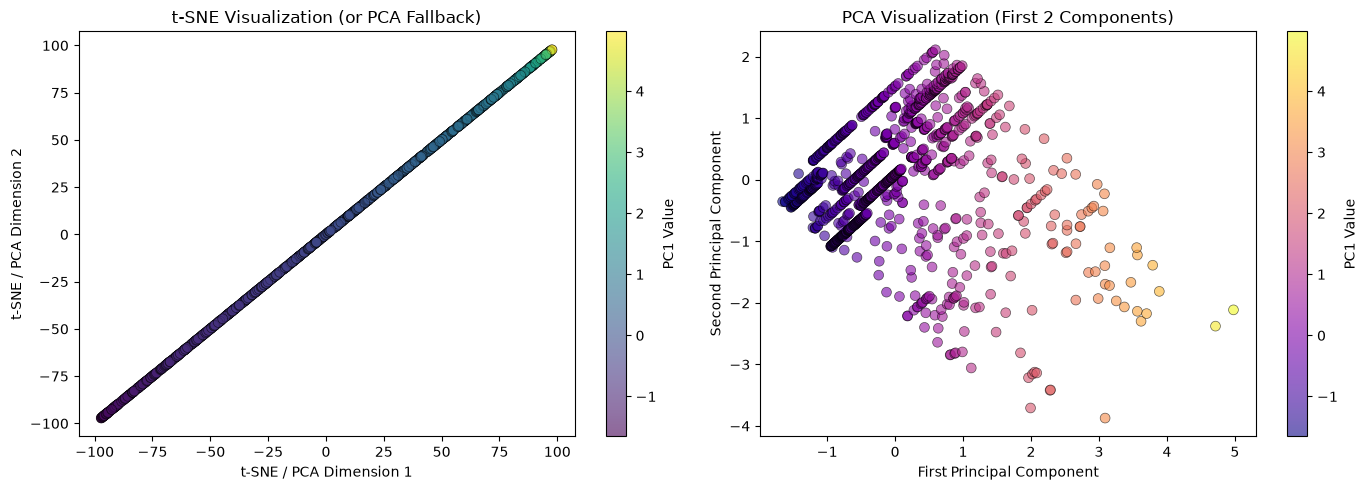


✅ Visualization complete!


In [47]:
# Visualize t-SNE and PCA results
# If X_tsne doesn't exist, create it with PCA fallback
if 'X_tsne' not in locals():
    print("Warning: X_tsne not found. Creating fallback with PCA projection...")
    X_tsne = X_pca[:, :2] if X_pca.shape[1] >= 2 else np.column_stack([X_pca[:, 0], X_pca[:, 0]])
    
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: t-SNE or PCA fallback
scatter1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                           c=X_pca[:, 0], cmap='viridis', 
                           alpha=0.6, s=50, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('t-SNE / PCA Dimension 1')
axes[0].set_ylabel('t-SNE / PCA Dimension 2')
axes[0].set_title('t-SNE Visualization (or PCA Fallback)')
plt.colorbar(scatter1, ax=axes[0], label='PC1 Value')

# Plot 2: PCA 2D projection (first 2 components)
if X_pca.shape[1] >= 2:
    scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], 
                               c=X_pca[:, 0], cmap='plasma', 
                               alpha=0.6, s=50, edgecolor='black', linewidth=0.5)
    axes[1].set_xlabel('First Principal Component')
    axes[1].set_ylabel('Second Principal Component')
    axes[1].set_title('PCA Visualization (First 2 Components)')
elif X_pca.shape[1] == 1:
    scatter2 = axes[1].scatter(X_pca[:, 0], [0]*len(X_pca), 
                               c=X_pca[:, 0], cmap='plasma', 
                               alpha=0.6, s=50, edgecolor='black', linewidth=0.5)
    axes[1].set_xlabel('First Principal Component')
    axes[1].set_ylabel('(No second component)')
    axes[1].set_title('PCA Visualization (Only 1 Component Available)')

plt.colorbar(scatter2, ax=axes[1], label='PC1 Value')

plt.tight_layout()
plt.show()

print("\n✅ Visualization complete!")


In [48]:
# Summary comparison
print("="*70)
print("DIMENSIONALITY REDUCTION SUMMARY")
print("="*70)

print(f"\n📊 ORIGINAL DATA:")
print(f"  Shape: {X.shape}")
print(f"  Number of features: {X.shape[1]}")

print(f"\n📉 PCA REDUCTION (95% variance):")
print(f"  Shape: {X_pca.shape}")
print(f"  Number of features: {X_pca.shape[1]}")
print(f"  Variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"  Reduction: {((X.shape[1] - X_pca.shape[1]) / X.shape[1] * 100):.2f}% fewer features")

print(f"\n🎯 t-SNE REDUCTION (for visualization):")
print(f"  Shape: {X_tsne.shape}")
print(f"  Purpose: Visualization and pattern discovery")
print(f"  Note: t-SNE does NOT preserve global structure as well as PCA")

print(f"\n✅ USE CASE RECOMMENDATIONS:")
print(f"  PCA: Use for modeling, preserves variance and interpretability")
print(f"  t-SNE: Use for visualization, finds non-linear patterns")

print("="*70)


DIMENSIONALITY REDUCTION SUMMARY

📊 ORIGINAL DATA:
  Shape: (1171, 2)
  Number of features: 2

📉 PCA REDUCTION (95% variance):
  Shape: (1171, 2)
  Number of features: 2
  Variance retained: 100.00%
  Reduction: 0.00% fewer features

🎯 t-SNE REDUCTION (for visualization):
  Shape: (1171, 2)
  Purpose: Visualization and pattern discovery
  Note: t-SNE does NOT preserve global structure as well as PCA

✅ USE CASE RECOMMENDATIONS:
  PCA: Use for modeling, preserves variance and interpretability
  t-SNE: Use for visualization, finds non-linear patterns


In [49]:
# Step 5: Save reduced data for future use in models
# Create DataFrames from reduced data
pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_columns)

tsne_columns = ['t-SNE_1', 't-SNE_2']
df_tsne = pd.DataFrame(X_tsne, columns=tsne_columns)

print("Reduced data saved as DataFrames:")
print(f"\nPCA DataFrame shape: {df_pca.shape}")
print(f"Columns: {df_pca.columns.tolist()}")
print(f"\nFirst 5 rows of PCA data:")
print(df_pca.head())

print(f"\n\nt-SNE DataFrame shape: {df_tsne.shape}")
print(f"Columns: {df_tsne.columns.tolist()}")
print(f"\nFirst 5 rows of t-SNE data:")
print(df_tsne.head())

# Optional: Combine with target variable if needed
# df_pca_with_target = pd.concat([df_pca, df['salary']], axis=1)
# df_pca_with_target.to_csv('data_reduced_pca.csv', index=False)
print("\n✅ Reduced data ready for machine learning models!")


Reduced data saved as DataFrames:

PCA DataFrame shape: (1171, 2)
Columns: ['PC1', 'PC2']

First 5 rows of PCA data:
        PC1       PC2
0  0.810379 -2.846187
1  0.181894 -2.213331
2 -0.947871 -1.081380
3  0.184079 -2.211146
4  0.815843 -2.840724


t-SNE DataFrame shape: (1171, 2)
Columns: ['t-SNE_1', 't-SNE_2']

First 5 rows of t-SNE data:
     t-SNE_1    t-SNE_2
0  63.037823  63.037823
1  22.949467  22.949467
2 -68.980362 -68.980362
3  23.037853  23.037853
4  63.448734  63.448734

✅ Reduced data ready for machine learning models!


In [51]:
# Step 6: Format all numerical columns to 1 decimal place
# Set pandas display format to show 1 decimal place
pd.options.display.float_format = '{:.1f}'.format

# Round numerical columns in main dataframe
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    df[col] = df[col].round(1)

# Round PCA dataframe
df_pca = df_pca.round(1)

# Round t-SNE dataframe
df_tsne = df_tsne.round(1)

print("✅ All numerical columns formatted to 1 decimal place!")
print("\nFormatted datasets:")
print(f"\nMain dataframe (first 5 rows):")
print(df.head())
print(f"\nPCA dataframe (first 5 rows):")
print(df_pca.head())
print(f"\nt-SNE dataframe (first 5 rows):")
print(df_tsne.head())


✅ All numerical columns formatted to 1 decimal place!

Formatted datasets:

Main dataframe (first 5 rows):
   id       job_title   job_type experience_level       location  salary
0   0  Data scientist  Full Time           Senior  New York City     0.6
1   2  Data scientist  Full Time           Senior         Boston     0.5
2   3  Data scientist  Full Time           Senior         London     0.2
3   4  Data scientist  Full Time           Senior         Boston     0.5
4   5  Data scientist  Full Time           Senior  New York City     0.6

PCA dataframe (first 5 rows):
   PC1  PC2
0  0.8 -2.8
1  0.2 -2.2
2 -0.9 -1.1
3  0.2 -2.2
4  0.8 -2.8

t-SNE dataframe (first 5 rows):
   t-SNE_1  t-SNE_2
0     63.0     63.0
1     22.9     22.9
2    -69.0    -69.0
3     23.0     23.0
4     63.4     63.4


In [61]:
# Step 7: Analyze data by experience level using ORIGINAL salary (not normalized)
# Reload df to get original USD salaries (before MinMaxScaler)
df_analysis = pd.read_csv("datascience_salaries.csv")
df_analysis = df_analysis.rename(columns={"Unnamed: 0": "id"})

# Apply currency conversion to get original USD salaries
conversion_rates = {"USD": 1.0, "EUR": 1.10, "GBP": 1.27}
df_analysis['salary_usd'] = df_analysis.apply(
    lambda row: row['salary'] * conversion_rates.get(row['salary_currency'], 1.0), 
    axis=1
)

# Use the original USD salary (before normalization)
df_analysis['salary'] = df_analysis['salary_usd']
df_analysis = df_analysis.drop(columns=['salary_currency', 'salary_usd'])

# Apply formatting
pd.options.display.float_format = '{:.1f}'.format
df_analysis['salary'] = df_analysis['salary'].round(1)

print("="*70)
print("SALARY ANALYSIS BY EXPERIENCE LEVEL (Original USD Salary)")
print("="*70)

# Group by experience level and calculate statistics
grouped_stats = df_analysis.groupby("experience_level").agg({
    'salary': ['count', 'mean', 'median', 'min', 'max', 'std']
}).round(1)

print("\nSalary Statistics by Experience Level:")
print(grouped_stats)

# More detailed analysis
print("\n" + "="*70)
print("DETAILED BREAKDOWN:")
print("="*70)

for level in df_analysis['experience_level'].unique():
    level_data = df_analysis[df_analysis['experience_level'] == level]['salary']
    print(f"\n📊 {level}:")
    print(f"   Count: {len(level_data)}")
    print(f"   Mean Salary: ${level_data.mean():,.1f}")
    print(f"   Median Salary: ${level_data.median():,.1f}")
    print(f"   Range: ${level_data.min():,.1f} - ${level_data.max():,.1f}")
    print(f"   Std Dev: ${level_data.std():,.1f}")


SALARY ANALYSIS BY EXPERIENCE LEVEL (Original USD Salary)

Salary Statistics by Experience Level:
                 salary                                         
                  count    mean  median     min      max     std
experience_level                                                
Entry               126 36111.1 30000.0 30000.0 140000.0 16151.4
Executive            13 76076.9 46000.0 41000.0 175000.0 46860.5
Mid                 305 51994.9 51000.0 30000.0 160000.0 20665.6
Senior              727 75152.8 68000.0 30000.0 228000.0 33524.3

DETAILED BREAKDOWN:

📊 Senior:
   Count: 727
   Mean Salary: $75,152.8
   Median Salary: $68,000.0
   Range: $30,000.0 - $228,000.0
   Std Dev: $33,524.3

📊 Entry:
   Count: 126
   Mean Salary: $36,111.1
   Median Salary: $30,000.0
   Range: $30,000.0 - $140,000.0
   Std Dev: $16,151.4

📊 Mid:
   Count: 305
   Mean Salary: $51,994.9
   Median Salary: $51,000.0
   Range: $30,000.0 - $160,000.0
   Std Dev: $20,665.6

📊 Executive:
   Count: 13
 